## 1. Imports & Configuration

In [1]:
import os
import h5py
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr
from skimage.metrics import structural_similarity as ssim
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')


SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')

Device : cuda


Paths & hyperparameters

In [2]:

DATA_DIR   = './data/'
SUBJECT    = 'subj01'
N_SAMPLES  = 5000

# Training
IMG_SIZE    = 64
LATENT_DIM  = 512
FMRI_DIM    = 256
BATCH_SIZE  = 64
LR          = 3e-4
EPOCHS      = 60
LAMBDA_NEURO = 0.1
LAMBDA_GEO   = 0.5

ALL_ROIS = ['V1', 'V2', 'V3', 'hV4', 'OFA', 'FFA', 'OPA', 'EBA', 'PPA', 'IPS']

# Map each ROI to encoder stage index (0-based, matching the 4 conv_block stages)
ROI_STAGE_MAP = {
    'V1': 0, 'V2': 0, 'V3': 0,# early visual : stage 0
    'hV4': 1, 'OFA': 1,# mid-ventral : stage 1
    'FFA': 2, 'OPA': 2, 'EBA': 2,# higher areas : stage 2
    'PPA': 3, 'IPS': 3,# top areas : stage 3
}

TARGET_ROIS = ['V1', 'V2', 'V3', 'hV4']

print(f'N_SAMPLES={N_SAMPLES} | IMG_SIZE={IMG_SIZE} | LATENT_DIM={LATENT_DIM}')
print(f'EPOCHS={EPOCHS} | BATCH_SIZE={BATCH_SIZE} | LAMBDA_NEURO={LAMBDA_NEURO}')


N_SAMPLES=5000 | IMG_SIZE=64 | LATENT_DIM=512
EPOCHS=60 | BATCH_SIZE=64 | LAMBDA_NEURO=0.1


## 2. ROI Map & Mask Loading

In [3]:
V1_MNI = np.array([8, -84, 2])

NSD_ROI_MAP = {
    'V1': ('prf-visualrois.nii.gz', [1, 2], np.array([8, -84, 2]), '#1f77b4'),
    'V2': ('prf-visualrois.nii.gz', [3, 4], np.array([8, -80, 10]), '#ff7f0e'),
    'V3': ('prf-visualrois.nii.gz', [5, 6], np.array([10, -74, 16]), '#2ca02c'),
    'hV4': ('prf-visualrois.nii.gz', [7], np.array([28, -64, -8]), '#d62728'),
    'OFA': ('floc-faces.nii.gz', [1], np.array([38, -76, -12]), '#9467bd'),
    'FFA': ('floc-faces.nii.gz', [2, 3], np.array([40, -52, -14]), '#e377c2'),
    'OPA': ('floc-places.nii.gz', [1], np.array([36, -76, 30]), '#7f7f7f'),
    'PPA': ('floc-places.nii.gz', [3], np.array([26, -46, -10]), '#bcbd22'),
    'EBA': ('floc-bodies.nii.gz', [1], np.array([46, -66, 2]), '#8c564b'),
    'IPS': ('streams.nii.gz', [7], np.array([24, -60, 54]), '#17becf'),
}


def load_roi_masks(roi_map, roi_dir, brain_shape):
    masks = {}
    atlas_cache = {}
    for roi_name, (atlas_file, label_ids, _, _) in roi_map.items():
        atlas_path = os.path.join(roi_dir, atlas_file)
        if not os.path.exists(atlas_path):
            print(f'[WARN] Atlas not found: {atlas_path} - skipping {roi_name}')
            continue
        if atlas_file not in atlas_cache:
            raw = nib.load(atlas_path).get_fdata().astype(int)
            if raw.shape != brain_shape:
                raise ValueError(f'Shape mismatch {atlas_file}: {raw.shape} vs {brain_shape}')
            atlas_cache[atlas_file] = raw
        atlas_data = atlas_cache[atlas_file]
        mask = np.zeros(brain_shape, dtype=bool)
        for lbl in label_ids:
            mask |= (atlas_data == lbl)
        masks[roi_name] = mask
        print(f'  {roi_name}: {mask.sum()} voxels')
    return masks


print('ROI map defined.')

ROI map defined.


## 3. Data Loading

In [4]:
index = pd.read_csv(DATA_DIR + 'trial_index.csv')
subject_index = index[index['subject'] == SUBJECT].copy()

new_index = (
    subject_index
    .groupby('nsd_stim_id')
    .filter(lambda g: len(g) == 3)
    .groupby('nsd_stim_id')['file_path']
    .apply(list)
    .apply(pd.Series)
    .reset_index()
)
new_index.columns = ['nsd_stim_id', 'file_path1', 'file_path2', 'file_path3']

n_available = len(new_index)
n_load = min(N_SAMPLES, n_available)
print(f'{n_available} stimuli with 3 repetitions found → loading {n_load}')

10000 stimuli with 3 repetitions found → loading 5000


Load and average fMRI volumes

In [5]:
fmri_volumes = []
stim_ids = []

for i in tqdm(range(n_load), desc='Loading fMRI volumes'):
    row = new_index.iloc[i]
    vols = []
    for k in range(1, 4):
        nii = nib.load(DATA_DIR + row[f'file_path{k}'])
        vols.append(torch.tensor(nii.get_fdata(dtype=np.float32)))
    fmri_volumes.append(torch.stack(vols).mean(0))
    stim_ids.append(int(row['nsd_stim_id']))

fmri_tensor = torch.stack(fmri_volumes)
BRAIN_SHAPE = tuple(fmri_tensor.shape[1:])
print(f'fMRI tensor : {fmri_tensor.shape} BRAIN_SHAPE={BRAIN_SHAPE}')

Loading fMRI volumes: 100%|██████████| 5000/5000 [02:33<00:00, 32.54it/s]


fMRI tensor : torch.Size([5000, 81, 104, 83]) BRAIN_SHAPE=(81, 104, 83)


Load ROI masks & build fMRI feature vector

In [6]:
roi_dir = os.path.join(DATA_DIR, 'roi_masks', SUBJECT)
roi_masks = load_roi_masks(NSD_ROI_MAP, roi_dir, BRAIN_SHAPE)

# Concatenate mean response across TARGET_ROIS
fmri_np = fmri_tensor.numpy()
roi_signals = []
for roi in TARGET_ROIS:
    if roi in roi_masks:
        sig = fmri_np[:, roi_masks[roi]].mean(axis=1)   # (N,)
        roi_signals.append(sig)
    else:
        print(f'[WARN] {roi} mask not available, skipping.')

fmri_features = np.stack(roi_signals, axis=1).astype(np.float32)  # (N, n_rois)

# Z-score normalisation per ROI
fmri_mean = fmri_features.mean(axis=0, keepdims=True)
fmri_std = fmri_features.std(axis=0, keepdims=True) + 1e-8
fmri_features = (fmri_features - fmri_mean) / fmri_std

fmri_dim_actual = fmri_features.shape[1]
print(f'fMRI feature matrix : {fmri_features.shape} (ROIs: {TARGET_ROIS})')

# Build per-ROI signal dict for ALL ROIs (used by Model 4 geo-reg)
all_roi_signals_np = {}
for roi in ALL_ROIS:
    if roi in roi_masks:
        sig = fmri_np[:, roi_masks[roi]].mean(axis=1).astype(np.float32)
        sig = (sig - sig.mean()) / (sig.std() + 1e-8)
        all_roi_signals_np[roi] = sig
    else:
        print(f'[WARN] {roi} not available for geo-reg, will be skipped')

# Stack into a tensor (N, n_available_rois)
geo_roi_names  = [r for r in ALL_ROIS if r in all_roi_signals_np]
geo_fmri_matrix = np.stack([all_roi_signals_np[r] for r in geo_roi_names], axis=1)  # (N, R)
print(f'Geo-reg fMRI matrix : {geo_fmri_matrix.shape} (ROIs: {geo_roi_names})')


  V1: 1350 voxels
  V2: 1433 voxels
  V3: 1187 voxels
  hV4: 687 voxels
  OFA: 355 voxels
  FFA: 794 voxels
  OPA: 1611 voxels
  PPA: 566 voxels
  EBA: 2971 voxels
  IPS: 3548 voxels
fMRI feature matrix : (5000, 4) (ROIs: ['V1', 'V2', 'V3', 'hV4'])
Geo-reg fMRI matrix : (5000, 10) (ROIs: ['V1', 'V2', 'V3', 'hV4', 'OFA', 'FFA', 'OPA', 'EBA', 'PPA', 'IPS'])


Load stimulus images

In [7]:
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

images = []
with h5py.File(DATA_DIR + 'nsd_stimuli.hdf5', 'r') as f_stim:
    for i, sid in enumerate(tqdm(stim_ids, desc='Loading images')):
        img_np = f_stim['imgBrick'][sid]
        images.append(transform(Image.fromarray(img_np)))

images = torch.stack(images)
print(f'Images tensor : {images.shape}')


Loading images: 100%|██████████| 5000/5000 [00:06<00:00, 795.36it/s]

Images tensor : torch.Size([5000, 3, 64, 64])


## 4. Dataset & DataLoaders


In [8]:
class NSDDataset(Dataset):

    def __init__(self, images, fmri, geo_fmri):
        self.images = images
        self.fmri = torch.tensor(fmri, dtype=torch.float32)
        self.geo_fmri = torch.tensor(geo_fmri, dtype=torch.float32)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        return self.images[idx], self.fmri[idx], self.geo_fmri[idx]


full_dataset = NSDDataset(images, fmri_features, geo_fmri_matrix)

n_total = len(full_dataset)
n_test = int(n_total * 0.15)
n_val = int(n_total * 0.10)
n_train = n_total - n_val - n_test

train_ds, val_ds, test_ds = random_split(
    full_dataset, [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(SEED)
)

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_dl = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_dl = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f'Train: {n_train} | Val: {n_val} | Test: {n_test}')


Train: 3750 | Val: 500 | Test: 750


## 5. Model Architectures

In [9]:
def conv_block(in_ch, out_ch):
    return nn.Sequential(
        nn.Conv2d(in_ch, out_ch, 3, stride=2, padding=1),
        nn.BatchNorm2d(out_ch),
        nn.LeakyReLU(0.2, inplace=True),
    )


def deconv_block(in_ch, out_ch, last=False):
    return nn.Sequential(
        nn.ConvTranspose2d(in_ch, out_ch, 4, stride=2, padding=1),
        nn.BatchNorm2d(out_ch) if not last else nn.Identity(),
        nn.ReLU(inplace=True) if not last else nn.Sigmoid(),
    )


class ConvEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            conv_block(3, 32),
            conv_block(32, 64),
            conv_block(64, 128),
            conv_block(128, 256),
        )
        self.fc = nn.Linear(256 * 4 * 4, LATENT_DIM)

    def forward(self, x):
        h = self.net(x).flatten(1)
        return self.fc(h)


class ConvDecoder(nn.Module):
    def __init__(self, dec_dim=LATENT_DIM):
        super().__init__()
        self.fc  = nn.Linear(dec_dim, 256 * 4 * 4)
        self.net = nn.Sequential(
            deconv_block(256, 128),
            deconv_block(128, 64),
            deconv_block(64, 32),
            deconv_block(32, 3, last=True),
        )

    def forward(self, z):
        h = self.fc(z).view(-1, 256, 4, 4)
        return self.net(h)

Model 1 - Baseline Autoencoder  (image-only)

In [10]:
class BaselineAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = ConvEncoder()
        self.decoder = ConvDecoder(LATENT_DIM)

    def forward(self, x):
        z = self.encoder(x)
        recon = self.decoder(z)
        return recon, z

    def encode(self, x): return self.encoder(x)
    def decode(self, z): return self.decoder(z)

Model 2 - Loss-Guided Autoencoder  (neuro regularisation in loss)

In [11]:
class LossGuidedAE(nn.Module):
    def __init__(self, fmri_dim):
        super().__init__()
        self.encoder = ConvEncoder()
        self.decoder = ConvDecoder(LATENT_DIM)
        self.fmri_head = nn.Sequential(
            nn.Linear(LATENT_DIM, 256),
            nn.ReLU(),
            nn.Linear(256, fmri_dim),
        )

    def forward(self, x):
        z = self.encoder(x)
        recon = self.decoder(z)
        fmri_pred = self.fmri_head(z)
        return recon, z, fmri_pred

    def encode(self, x):  return self.encoder(x)
    def decode(self, z):  return self.decoder(z)

Model 3 - Concat-Guided Autoencoder  (fMRI injected before decoder)

In [12]:
class ConcatGuidedAE(nn.Module):

    def __init__(self, fmri_dim):
        super().__init__()
        self.encoder = ConvEncoder()
        self.fmri_proj = nn.Sequential(
            nn.Linear(fmri_dim, FMRI_DIM),
            nn.ReLU(),
            nn.Linear(FMRI_DIM, FMRI_DIM),
        )
        self.decoder = ConvDecoder(LATENT_DIM + FMRI_DIM)

    def forward(self, x, fmri):
        z_img = self.encoder(x)
        z_fmri = self.fmri_proj(fmri)
        z_cat = torch.cat([z_img, z_fmri], dim=1)
        recon = self.decoder(z_cat)
        return recon, z_img, z_fmri

    def encode(self, x):  return self.encoder(x)

Model 4 — Brain Geometry Regularized Autoencoder

In [13]:
class StagedConvEncoder(nn.Module):

    def __init__(self):
        super().__init__()
        self.stage0 = conv_block(3, 32)
        self.stage1 = conv_block(32, 64)
        self.stage2 = conv_block(64, 128)
        self.stage3 = conv_block(128, 256)
        self.fc = nn.Linear(256 * 4 * 4, LATENT_DIM)

    def forward(self, x):
        s0 = self.stage0(x)
        s1 = self.stage1(s0)
        s2 = self.stage2(s1)
        s3 = self.stage3(s2)
        z = self.fc(s3.flatten(1))
        return z, [s0, s1, s2, s3]

class GeoRegAE(nn.Module):

    def __init__(self, geo_roi_names, roi_stage_map):
        super().__init__()
        self.encoder = StagedConvEncoder()
        self.decoder = ConvDecoder(LATENT_DIM)

        stage_channels = [32, 64, 128, 256]

        self.probes = nn.ModuleDict()
        for roi in geo_roi_names:
            stage_idx = roi_stage_map.get(roi, 3)
            in_dim = stage_channels[stage_idx]
            self.probes[roi] = nn.Linear(in_dim, 1)

        self.geo_roi_names = geo_roi_names
        self.roi_stage_map = roi_stage_map

    def forward(self, x):
        z, stage_maps = self.encoder(x)
        recon = self.decoder(z)

        roi_preds = {}
        for roi in self.geo_roi_names:
            stage_idx  = self.roi_stage_map.get(roi, 3)
            fmap = stage_maps[stage_idx]
            gap = fmap.mean(dim=[2, 3])
            roi_preds[roi] = self.probes[roi](gap).squeeze(1)

        return recon, z, roi_preds

    def encode(self, x):
        z, _ = self.encoder(x)
        return z

    def decode(self, z):
        return self.decoder(z)


def geo_reg_loss(roi_preds, geo_fmri_batch, geo_roi_names):

    total = torch.zeros(1, device=geo_fmri_batch.device)
    for ri, roi in enumerate(geo_roi_names):
        total = total + F.mse_loss(roi_preds[roi], geo_fmri_batch[:, ri])
    return total / max(len(geo_roi_names), 1)

## 6. Training

Generic training utilities

In [14]:
def train_epoch_baseline(model, loader, optimizer, criterion):
    model.train()
    total = 0
    for imgs, _, __ in loader:
        imgs = imgs.to(DEVICE)
        optimizer.zero_grad()
        recon, _ = model(imgs)
        loss = criterion(recon, imgs)
        loss.backward()
        optimizer.step()
        total += loss.item()
    return total / len(loader)


@torch.no_grad()
def eval_epoch_baseline(model, loader, criterion):
    model.eval()
    total = 0
    for imgs, _, __ in loader:
        imgs = imgs.to(DEVICE)
        recon, _ = model(imgs)
        total += criterion(recon, imgs).item()
    return total / len(loader)


def train_epoch_loss_guided(model, loader, optimizer, criterion, lam):
    model.train()
    total_recon, total_neuro = 0, 0
    for imgs, fmri, _ in loader:
        imgs, fmri = imgs.to(DEVICE), fmri.to(DEVICE)
        optimizer.zero_grad()
        recon, _, fmri_pred = model(imgs)
        l_recon = criterion(recon, imgs)
        l_neuro = criterion(fmri_pred, fmri)
        loss = l_recon + lam * l_neuro
        loss.backward()
        optimizer.step()
        total_recon += l_recon.item()
        total_neuro += l_neuro.item()
    return total_recon / len(loader), total_neuro / len(loader)


@torch.no_grad()
def eval_epoch_loss_guided(model, loader, criterion):
    model.eval()
    total = 0
    for imgs, _, __ in loader:
        imgs = imgs.to(DEVICE)
        recon, _, _ = model(imgs)
        total += criterion(recon, imgs).item()
    return total / len(loader)


def train_epoch_concat(model, loader, optimizer, criterion):
    model.train()
    total = 0
    for imgs, fmri, _ in loader:
        imgs, fmri = imgs.to(DEVICE), fmri.to(DEVICE)
        optimizer.zero_grad()
        recon, _, _ = model(imgs, fmri)
        loss = criterion(recon, imgs)
        loss.backward()
        optimizer.step()
        total += loss.item()
    return total / len(loader)


@torch.no_grad()
def eval_epoch_concat(model, loader, criterion):
    model.eval()
    total = 0
    for imgs, fmri, _ in loader:
        imgs, fmri = imgs.to(DEVICE), fmri.to(DEVICE)
        recon, _, _ = model(imgs, fmri)
        total += criterion(recon, imgs).item()
    return total / len(loader)

Model 4 : Geo-Reg training utilities

In [15]:
def train_epoch_georeg(model, loader, optimizer, criterion, lam_geo, geo_roi_names):
    model.train()
    total_recon, total_geo = 0, 0
    for imgs, _, geo_fmri in loader:
        imgs     = imgs.to(DEVICE)
        geo_fmri = geo_fmri.to(DEVICE)
        optimizer.zero_grad()
        recon, _, roi_preds = model(imgs)
        l_recon = criterion(recon, imgs)
        l_geo   = geo_reg_loss(roi_preds, geo_fmri, geo_roi_names)
        loss    = l_recon + lam_geo * l_geo
        loss.backward()
        optimizer.step()
        total_recon += l_recon.item()
        total_geo   += l_geo.item()
    return total_recon / len(loader), total_geo / len(loader)

@torch.no_grad()
def eval_epoch_georeg(model, loader, criterion):
    model.eval()
    total = 0
    for imgs, _, __ in loader:
        imgs = imgs.to(DEVICE)
        recon, _, _ = model(imgs)
        total += criterion(recon, imgs).item()
    return total / len(loader)

Model 1 : Baseline

In [16]:
m1 = BaselineAE().to(DEVICE)
opt1 = optim.Adam(m1.parameters(), lr=LR)
scheduler1 = optim.lr_scheduler.CosineAnnealingLR(opt1, T_max=EPOCHS)
criterion  = nn.MSELoss()

hist_m1 = {'train': [], 'val': []}
for epoch in range(1, EPOCHS + 1):
    tr = train_epoch_baseline(m1, train_dl, opt1, criterion)
    vl = eval_epoch_baseline(m1, val_dl, criterion)
    scheduler1.step()
    hist_m1['train'].append(tr)
    hist_m1['val'].append(vl)
    if epoch % 10 == 0:
        print(f'Epoch {epoch}/{EPOCHS} : train: {tr}, val: {vl}')

Epoch 10/60 : train: 0.011438968433540756, val: 0.011733800056390464
Epoch 20/60 : train: 0.008244142244112188, val: 0.010144247789867222
Epoch 30/60 : train: 0.006744576049810749, val: 0.008351334487088025
Epoch 40/60 : train: 0.005938474167832884, val: 0.00807550543686375
Epoch 50/60 : train: 0.005586939958571378, val: 0.008113673655316234
Epoch 60/60 : train: 0.005577326681212348, val: 0.00803775351960212


Model 2 : Loss-Guided

In [17]:
m2 = LossGuidedAE(fmri_dim=fmri_dim_actual).to(DEVICE)
opt2 = optim.Adam(m2.parameters(), lr=LR)
scheduler2 = optim.lr_scheduler.CosineAnnealingLR(opt2, T_max=EPOCHS)

hist_m2 = {'train_recon': [], 'train_neuro': [], 'val': []}
for epoch in range(1, EPOCHS + 1):
    tr_r, tr_n = train_epoch_loss_guided(m2, train_dl, opt2, criterion, LAMBDA_NEURO)
    vl = eval_epoch_loss_guided(m2, val_dl, criterion)
    scheduler2.step()
    hist_m2['train_recon'].append(tr_r)
    hist_m2['train_neuro'].append(tr_n)
    hist_m2['val'].append(vl)
    if epoch % 10 == 0:
        print(f'Epoch {epoch}/{EPOCHS} — recon: {tr_r}  neuro: {tr_n}  val: {vl}')

Epoch 10/60 — recon: 0.013819774565429  neuro: 0.06058208764357082  val: 0.015770730562508106
Epoch 20/60 — recon: 0.009765733522757634  neuro: 0.01833122002623849  val: 0.013315658550709486
Epoch 30/60 — recon: 0.007967804763781823  neuro: 0.0074276003781390395  val: 0.012454696465283632
Epoch 40/60 — recon: 0.006974712827132415  neuro: 0.0036001055347496423  val: 0.012178007047623396
Epoch 50/60 — recon: 0.006505284505754204  neuro: 0.0019157498244243532  val: 0.01212211255915463
Epoch 60/60 — recon: 0.00639645092315593  neuro: 0.0014585657755575947  val: 0.01215437229257077


Model 3 : Concat-Guided

In [18]:
m3 = ConcatGuidedAE(fmri_dim=fmri_dim_actual).to(DEVICE)
opt3 = optim.Adam(m3.parameters(), lr=LR)
scheduler3 = optim.lr_scheduler.CosineAnnealingLR(opt3, T_max=EPOCHS)

hist_m3 = {'train': [], 'val': []}
for epoch in range(1, EPOCHS + 1):
    tr = train_epoch_concat(m3, train_dl, opt3, criterion)
    vl = eval_epoch_concat(m3, val_dl, criterion)
    scheduler3.step()
    hist_m3['train'].append(tr)
    hist_m3['val'].append(vl)
    if epoch % 10 == 0:
        print(f'Epoch {epoch}/{EPOCHS} — train: {tr}  val: {vl}')

print('Done.')

Epoch 10/60 — train: 0.01145386591679969  val: 0.01241731841582805
Epoch 20/60 — train: 0.008202250597019822  val: 0.009612854570150375
Epoch 30/60 — train: 0.006784504421560441  val: 0.008865441312082112
Epoch 40/60 — train: 0.00594789956270133  val: 0.00844781391788274
Epoch 50/60 — train: 0.005575244678026539  val: 0.008365661080460995
Epoch 60/60 — train: 0.0054781877640950475  val: 0.008284663024824113
Done.


Model 4 : Brain Geometry Regularized

In [19]:
m4 = GeoRegAE(geo_roi_names=geo_roi_names, roi_stage_map=ROI_STAGE_MAP).to(DEVICE)
opt4 = optim.Adam(m4.parameters(), lr=LR)
scheduler4 = optim.lr_scheduler.CosineAnnealingLR(opt4, T_max=EPOCHS)

hist_m4 = {'train_recon': [], 'train_geo': [], 'val': []}
for epoch in range(1, EPOCHS + 1):
    tr_r, tr_g = train_epoch_georeg(m4, train_dl, opt4, criterion, LAMBDA_GEO, geo_roi_names)
    vl = eval_epoch_georeg(m4, val_dl, criterion)
    scheduler4.step()
    hist_m4['train_recon'].append(tr_r)
    hist_m4['train_geo'].append(tr_g)
    hist_m4['val'].append(vl)
    if epoch % 10 == 0:
        print(f'  Epoch {epoch}/{EPOCHS} — recon: {tr_r}  geo: {tr_g}  val: {vl}')

  Epoch 10/60 — recon: 0.012185464108015522  geo: 0.8334956441895437  val: 0.014674886595457792
  Epoch 20/60 — recon: 0.008771420559072393  geo: 0.7320269639209166  val: 0.013784748502075672
  Epoch 30/60 — recon: 0.007113343736125251  geo: 0.6967941310446141  val: 0.01418821804691106
  Epoch 40/60 — recon: 0.006135631944605355  geo: 0.681900283037606  val: 0.01470276981126517
  Epoch 50/60 — recon: 0.00570161752718485  geo: 0.6696616118237123  val: 0.015189320663921535
  Epoch 60/60 — recon: 0.0056125742967351  geo: 0.6696918192556349  val: 0.015152876148931682


Evaluation metrics helpers

In [20]:

def compute_metrics(originals, reconstructions):

    orig = originals.transpose(0, 2, 3, 1)
    recon = reconstructions.transpose(0, 2, 3, 1)

    mse_vals, psnr_vals, ssim_vals, r_vals = [], [], [], []

    for o, r in zip(orig, recon):
        mse = mean_squared_error(o.flatten(), r.flatten())
        psnr = 10 * np.log10(1.0 / (mse + 1e-10))
        s = ssim(o, r, data_range=1.0, channel_axis=2)
        corr, _ = pearsonr(o.flatten(), r.flatten())
        mse_vals.append(mse)
        psnr_vals.append(psnr)
        ssim_vals.append(s)
        r_vals.append(corr)

    return {
        'MSE': np.mean(mse_vals),
        'PSNR': np.mean(psnr_vals),
        'SSIM': np.mean(ssim_vals),
        'Pearson': np.mean(r_vals),
    }


@torch.no_grad()
def collect_test_outputs(model, loader, model_type='baseline'):

    model.eval()
    all_orig, all_recon = [], []
    for imgs, fmri, geo_fmri in loader:
        imgs = imgs.to(DEVICE)
        if model_type == 'concat':
            fmri = fmri.to(DEVICE)
            recon, _, _ = model(imgs, fmri)
        elif model_type in ('loss_guided', 'georeg'):
            recon, _, _ = model(imgs)
        else:
            recon, _ = model(imgs)
        all_orig.append(imgs.cpu().numpy())
        all_recon.append(recon.cpu().numpy())
    return np.concatenate(all_orig), np.concatenate(all_recon)

Compute metrics on test set

In [21]:
print('Evaluating on test set')

orig1, recon1 = collect_test_outputs(m1, test_dl, 'baseline')
orig2, recon2 = collect_test_outputs(m2, test_dl, 'loss_guided')
orig3, recon3 = collect_test_outputs(m3, test_dl, 'concat')
orig4, recon4 = collect_test_outputs(m4, test_dl, 'georeg')

metrics1 = compute_metrics(orig1, recon1)
metrics2 = compute_metrics(orig2, recon2)
metrics3 = compute_metrics(orig3, recon3)
metrics4 = compute_metrics(orig4, recon4)

results_df = pd.DataFrame({
    'Model': ['Baseline', 'Loss-Guided', 'Concat-Guided', 'Geo-Reg'],
    **{k: [metrics1[k], metrics2[k], metrics3[k], metrics4[k]] for k in metrics1}
})
results_df = results_df.set_index('Model')

print(results_df.round(5).to_string())


Evaluating on test set
                   MSE      PSNR     SSIM  Pearson
Model                                             
Baseline       0.00808  21.57373  0.61277  0.91705
Loss-Guided    0.01212  19.78747  0.51488  0.87462
Concat-Guided  0.00831  21.43888  0.60278  0.91465
Geo-Reg        0.01514  18.85409  0.48245  0.84460


## 8. Loss Curves

Validation loss overlay (apples-to-apples comparison) 

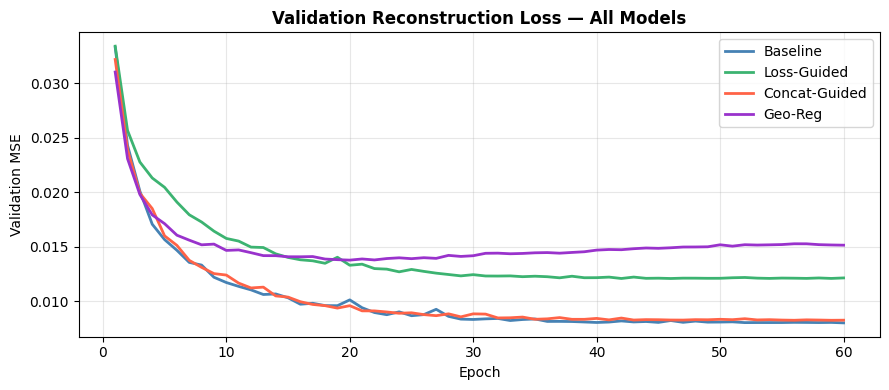

Saved: val_loss_comparison.png


In [22]:
epochs_x = np.arange(1, EPOCHS + 1)

# AI Generated

plt.figure(figsize=(9, 4))
plt.plot(epochs_x, hist_m1['val'],          label='Baseline',      color='steelblue',      linewidth=2)
plt.plot(epochs_x, hist_m2['val'],          label='Loss-Guided',   color='mediumseagreen', linewidth=2)
plt.plot(epochs_x, hist_m3['val'],          label='Concat-Guided', color='tomato',         linewidth=2)
plt.plot(epochs_x, hist_m4['val'],          label='Geo-Reg',       color='darkorchid',     linewidth=2)
plt.xlabel('Epoch'); plt.ylabel('Validation MSE')
plt.title('Validation Reconstruction Loss — All Models', fontweight='bold')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print('Saved: val_loss_comparison.png')


## 9. Metrics Bar Chart

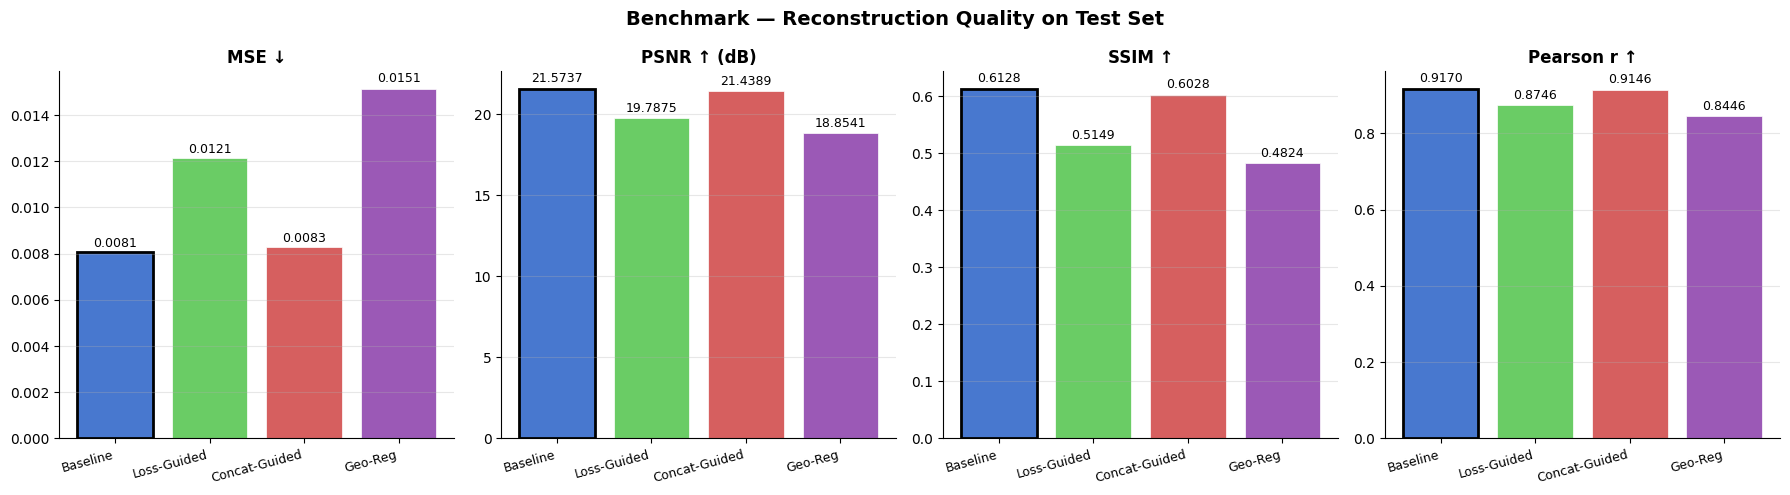

Saved: benchmark_metrics.png


In [23]:
# AI Generated

model_names  = ['Baseline', 'Loss-Guided', 'Concat-Guided', 'Geo-Reg']
model_colors = ['#4878CF', '#6ACC65', '#D65F5F', '#9B59B6']
metric_keys  = ['MSE', 'PSNR', 'SSIM', 'Pearson']
metric_labels = ['MSE ↓', 'PSNR ↑ (dB)', 'SSIM ↑', 'Pearson r ↑']

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for ax, key, label in zip(axes, metric_keys, metric_labels):
    vals = [results_df.loc[m, key] for m in model_names]
    bars = ax.bar(model_names, vals, color=model_colors, edgecolor='white', linewidth=0.5)
    # Star the best bar
    best_idx = vals.index(min(vals) if key == 'MSE' else max(vals))
    bars[best_idx].set_edgecolor('black')
    bars[best_idx].set_linewidth(2)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.01,
                f'{v:.4f}', ha='center', va='bottom', fontsize=9)
    ax.set_title(label, fontweight='bold')
    ax.set_xticklabels(model_names, rotation=15, ha='right', fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['right', 'top']].set_visible(False)

fig.suptitle('Benchmark — Reconstruction Quality on Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print('Saved: benchmark_metrics.png')


## 10. Visual Comparison

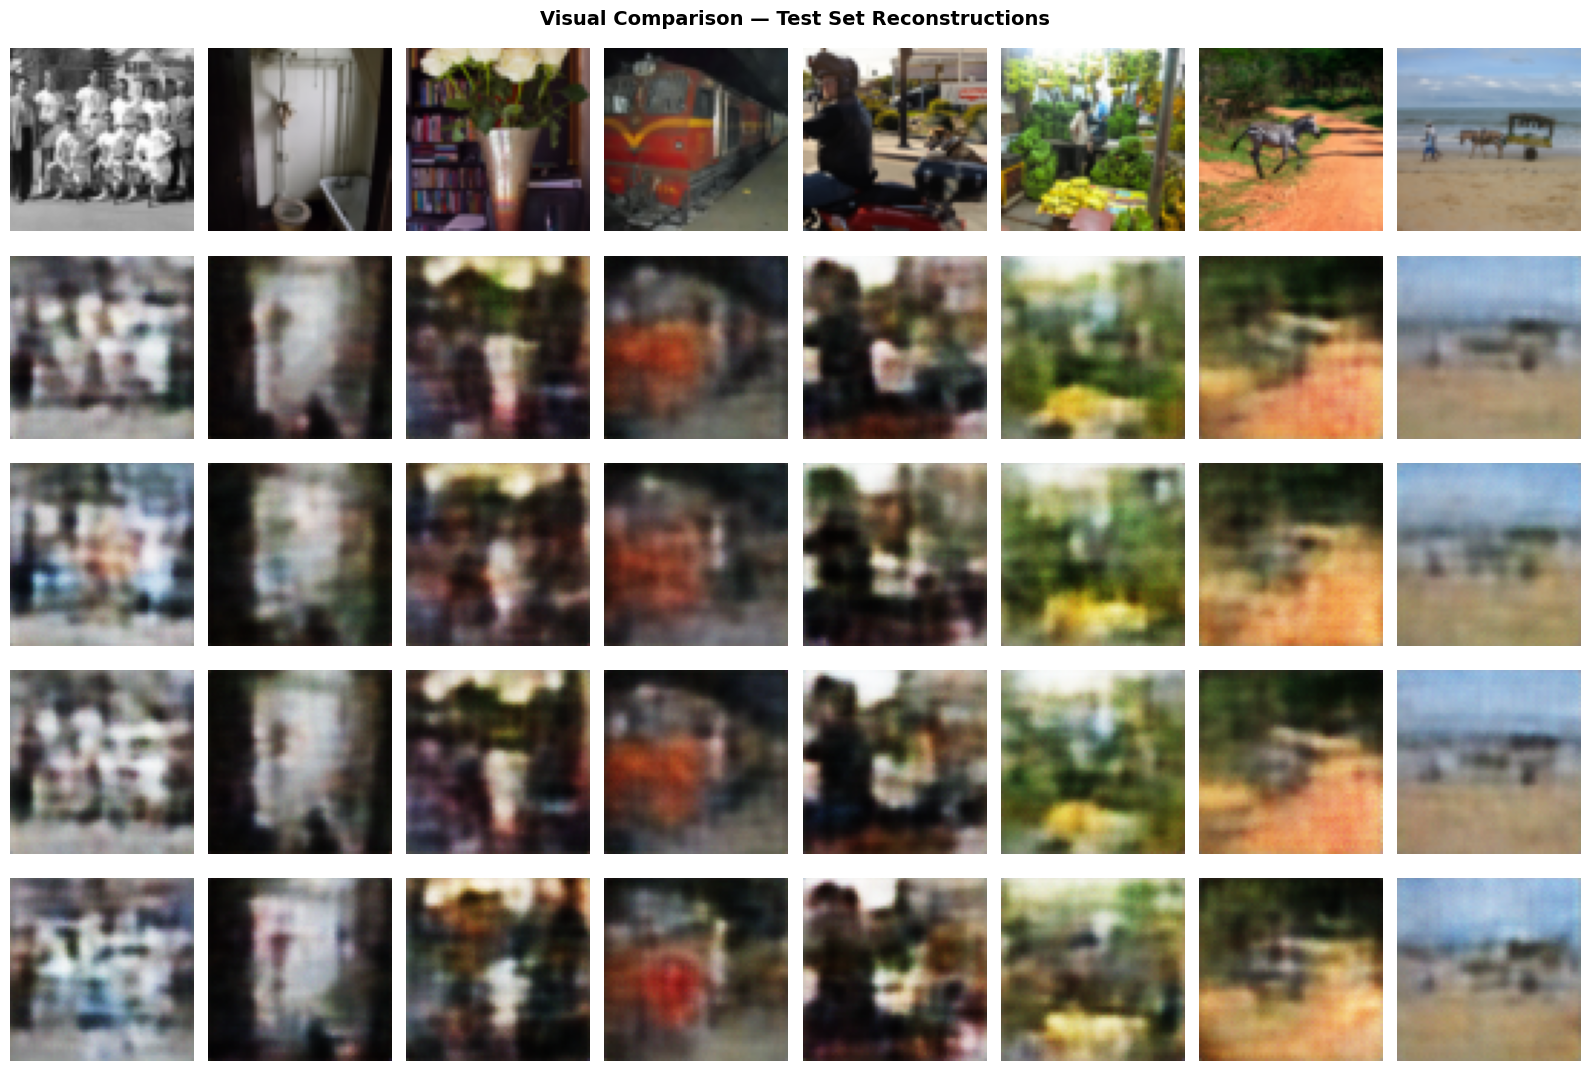

Saved: visual_comparison.png


In [24]:
# AI Generated

def to_img(arr):
    """(3, H, W) float array → (H, W, 3) clipped for display."""
    return np.clip(arr.transpose(1, 2, 0), 0, 1)


N_VIZ = 8   # number of test samples to show
indices = np.linspace(0, len(orig1) - 1, N_VIZ, dtype=int)

fig, axes = plt.subplots(5, N_VIZ, figsize=(N_VIZ * 2, 11))
row_labels = ['Original', 'Baseline', 'Loss-Guided', 'Concat-Guided', 'Geo-Reg']
row_data   = [orig1, recon1, recon2, recon3, recon4]

for row, (label, data) in enumerate(zip(row_labels, row_data)):
    for col, idx in enumerate(indices):
        ax = axes[row, col]
        ax.imshow(to_img(data[idx]))
        ax.axis('off')
        if col == 0:
            ax.set_ylabel(label, fontsize=11, fontweight='bold', rotation=0,
                          labelpad=80, va='center')

fig.suptitle('Visual Comparison — Test Set Reconstructions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print('Saved: visual_comparison.png')


## 11. Latent Space Analysis

In [25]:
@torch.no_grad()
def collect_latents_and_fmri(model, loader, model_type='baseline'):
    model.eval()
    zs, fmris = [], []
    for imgs, fmri, _ in loader:
        imgs = imgs.to(DEVICE)
        z = model.encode(imgs).cpu().numpy()
        zs.append(z)
        fmris.append(fmri.numpy())
    return np.concatenate(zs), np.concatenate(fmris)


z1, fmri_test = collect_latents_and_fmri(m1, test_dl, 'baseline')
z2, _          = collect_latents_and_fmri(m2, test_dl, 'loss_guided')
z3, _          = collect_latents_and_fmri(m3, test_dl, 'concat')
z4, _          = collect_latents_and_fmri(m4, test_dl, 'georeg')

# Pearson correlation between each latent dimension and each ROI signal
def latent_fmri_correlation(z, fmri):
    """Mean absolute Pearson r between latent dims and fMRI ROI signals."""
    n_rois = fmri.shape[1]
    rs = []
    for roi_idx in range(n_rois):
        roi_sig = fmri[:, roi_idx]
        r_per_dim = [abs(pearsonr(z[:, d], roi_sig)[0]) for d in range(z.shape[1])]
        rs.append(np.mean(r_per_dim))
    return np.array(rs)


corr1 = latent_fmri_correlation(z1, fmri_test)
corr2 = latent_fmri_correlation(z2, fmri_test)
corr3 = latent_fmri_correlation(z3, fmri_test)
corr4 = latent_fmri_correlation(z4, fmri_test)

print('Mean |Pearson r| between latent space and fMRI ROIs:')
for roi, c1, c2, c3, c4 in zip(TARGET_ROIS, corr1, corr2, corr3, corr4):
    print(f'  {roi:4s}  Baseline={c1:.4f}  Loss-Guided={c2:.4f}  Concat-Guided={c3:.4f}  Geo-Reg={c4:.4f}')


Mean |Pearson r| between latent space and fMRI ROIs:
  V1    Baseline=0.0673  Loss-Guided=0.1237  Concat-Guided=0.0693  Geo-Reg=0.0675
  V2    Baseline=0.0501  Loss-Guided=0.1055  Concat-Guided=0.0513  Geo-Reg=0.0519
  V3    Baseline=0.0453  Loss-Guided=0.0937  Concat-Guided=0.0463  Geo-Reg=0.0484
  hV4   Baseline=0.0416  Loss-Guided=0.0884  Concat-Guided=0.0416  Geo-Reg=0.0427


 Latent-fMRI correlation bar chart

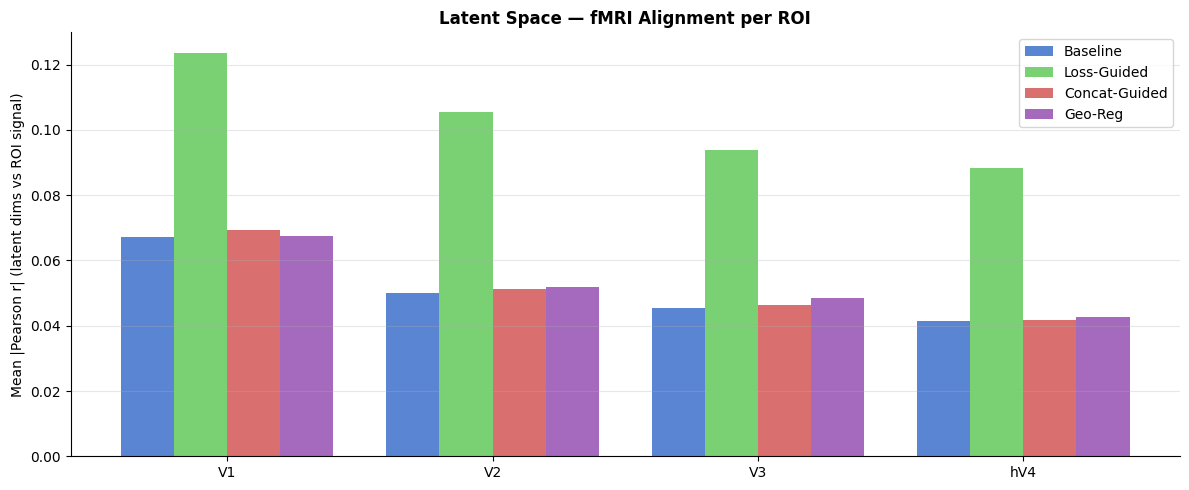

Saved: latent_fmri_alignment.png


In [26]:
# AI Generated

x   = np.arange(len(TARGET_ROIS))
w   = 0.2
fig, ax = plt.subplots(figsize=(12, 5))

ax.bar(x - 1.5*w, corr1, w, label='Baseline',       color='#4878CF', alpha=0.9)
ax.bar(x - 0.5*w, corr2, w, label='Loss-Guided',    color='#6ACC65', alpha=0.9)
ax.bar(x + 0.5*w, corr3, w, label='Concat-Guided',  color='#D65F5F', alpha=0.9)
ax.bar(x + 1.5*w, corr4, w, label='Geo-Reg',        color='#9B59B6', alpha=0.9)

ax.set_xticks(x); ax.set_xticklabels(TARGET_ROIS)
ax.set_ylabel('Mean |Pearson r| (latent dims vs ROI signal)')
ax.set_title('Latent Space — fMRI Alignment per ROI', fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
ax.spines[['right', 'top']].set_visible(False)
plt.tight_layout()
plt.show()
print('Saved: latent_fmri_alignment.png')
